<a href="https://www.pieriandata.com"><img src="data/Logo.jpg"></a>

# Image Basics Assessment

## Complete the Tasks in bold below. Keep in mind, you may need to run some of these tasks as Python scripts.

----------

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


#### TASK: Open the *dog_backpack.jpg* image from the `data` folder and display it in the notebook. Make sure to correct for the RGB order.

In [20]:
img = cv2.imread('data/dog_backpack.jpg')

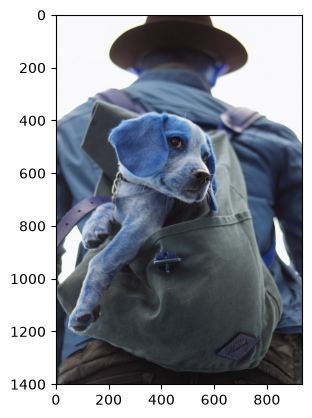

In [21]:
plt.imshow(img)

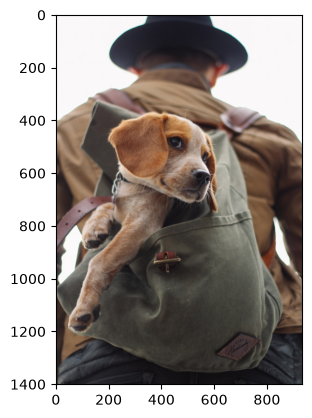

In [22]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

#### TASK: Flip the image upside down and display it in the notebook.

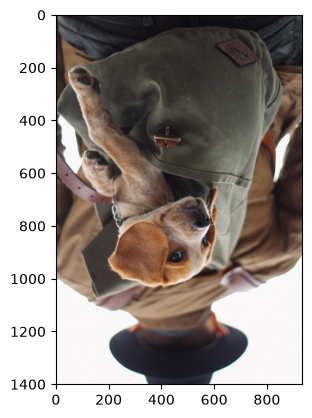

In [23]:
plt.imshow(cv2.flip(img_rgb, 0))

#### TASK: Draw an empty RED rectangle around the dogs face and display the image in the notebook.

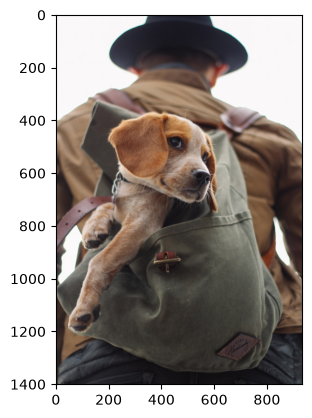

In [35]:
img_rgb_ = img_rgb.copy()
plt.imshow(img_rgb_)

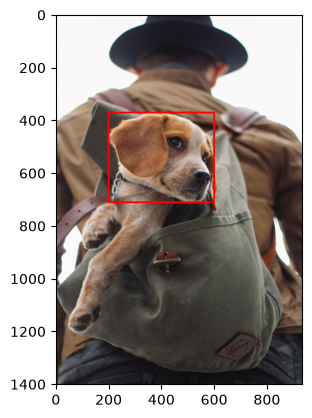

In [36]:
cv2.rectangle(img_rgb_, (200,370), (600,710), color=(255,0,0), thickness=5)
plt.imshow(img_rgb_)

#### TASK: Draw a BLUE TRIANGLE in the middle of the image. The size and angle is up to you, but it should be a triangle (three sides) in any orientation.

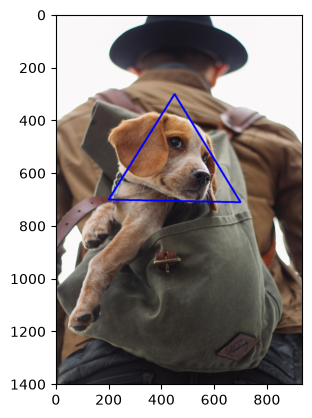

In [53]:
img_rgb_ = img_rgb.copy()
tri_pts = np.array([[200, 700],[700,710], [450,300]])
pts = tri_pts.reshape((-1,1,2))
cv2.polylines(img_rgb_, [pts], color=(0,0,255), thickness=5, isClosed=True)
plt.imshow(img_rgb_)

### BONUS TASK. Can you figure our how to fill in this triangle? It requires a different function that we didn't show in the lecture! See if you can use google search to find it.

[CLICK ME FOR A DIRECT LINK TO THE HINT](https://docs.opencv.org/3.0-beta/modules/imgproc/doc/drawing_functions.html#fillpoly)

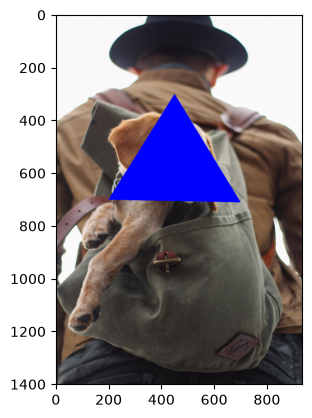

In [54]:
img_rgb_ = img_rgb.copy()
tri_pts = np.array([[200, 700],[700,710], [450,300]])
pts = tri_pts.reshape((-1,1,2))
cv2.fillPoly(img_rgb_, [pts], color=(0,0,255))
plt.imshow(img_rgb_)

#### TASK: (NOTE: YOU WILL NEED TO RUN THIS AS A SCRIPT). Create a script that opens the picture and allows you to draw empty red circles whever you click the RIGHT MOUSE BUTTON DOWN.

In [67]:
img_ = img.copy()

def draw_circle(event, x, y, flags, params):
    if event == cv2.EVENT_LBUTTONDOWN:
        global ix, iy, radius, drawing, img_
        drawing = True
        ix, iy = x, y

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            # Calculate radius from starting point to current pointer position
            radius = int(np.sqrt((x-ix)**2 + (y-iy)**2))
            # Reset image so previous circles don't remain
            img_ = img.copy()
            # Draw circle
            cv2.circle(img=img_, center=(ix,iy), radius=radius, color=(0,255,0), thickness=5)

    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
        # Calculate radius from starting point to current pointer position
        radius = int(np.sqrt((x-ix)**2 + (y-iy)**2))
        # Draw circle
        cv2.circle(img=img_, center=(ix,iy), radius=radius, color=(0,255,0), thickness=5)
    
ix, iy, radius, drawing = -1, -1, 0, False
cv2.namedWindow("My Photo")
cv2.setMouseCallback("My Photo", draw_circle)

while True:
    cv2.imshow("My Photo", img_)
    if cv2.waitKey(3) & 0xFF == 27:
        break

cv2.destroyAllWindows()